In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Reading in the data for part 2 of project

In [10]:
mdf = pd.read_csv('../data/lmf_parsed.csv', encoding='latin1')
mdf.head()

,SEQN,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM
0,1,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,1.0,6.0,0.0,0.0,177.0,177.0
2,3,2,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,0.0,NaN,NaN,NaN,244.0,244.0


In [14]:
gdf = pd.read_sas("../data/DEMO.xpt", format="xport")
gdf.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,WTIREP43,WTIREP44,WTIREP45,WTIREP46,WTIREP47,WTIREP48,WTIREP49,WTIREP50,WTIREP51,WTIREP52
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,10094.017100,9912.461855,9727.078709,10041.524113,9.953956e+03,9857.381983,9865.152486,10327.992682,9809.165049,10323.315747
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,27186.728682,27324.345051,28099.663528,27757.066921,2.804929e+04,26716.602006,26877.704909,27268.025234,27406.383620,26984.812909
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,43993.193099,44075.386428,46642.563799,44967.681579,4.457248e+04,44087.945688,44831.370881,44480.987235,45389.112766,43781.905637
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,10702.307249,10531.444441,10346.119327,10636.063039,5.397605e-79,10533.108939,10654.749584,10851.024385,10564.981435,11012.529729
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,93164.782430,92119.608772,95388.490406,94131.383538,9.529781e+04,91325.082461,91640.586117,92817.926915,94282.855382,91993.251203


In [17]:
df = gdf.merge(mdf, on="SEQN", how="inner")
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,WTIREP50,WTIREP51,WTIREP52,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,10327.992682,9809.165049,10323.315747,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,27268.025234,27406.383620,26984.812909,1,1.0,6.0,0.0,0.0,177.0,177.0
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,44480.987235,45389.112766,43781.905637,2,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,10851.024385,10564.981435,11012.529729,2,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,92817.926915,94282.855382,91993.251203,1,0.0,NaN,NaN,NaN,244.0,244.0


In [25]:
df = df[["ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX", "DMDEDUC2", "DMDMARTL", "DMDHHSIZ", "INDHHINC"]].dropna()
df = df.query("DMDEDUC2 < 7 and DMDMARTL < 77 and INDHHINC < 13")
df = df[df['ELIGSTAT'] == 1].copy()
df

,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX,DMDEDUC2,DMDMARTL,DMDHHSIZ,INDHHINC
4,1,0.0,244.0,597.0,5.0,1.0,3.0,11.0
11,1,0.0,236.0,454.0,4.0,5.0,4.0,11.0
12,1,1.0,16.0,850.0,1.0,1.0,2.0,3.0
13,1,1.0,137.0,974.0,2.0,3.0,1.0,5.0
14,1,0.0,231.0,460.0,5.0,3.0,2.0,8.0
...,...,...,...,...,...,...,...,...
9953,1,0.0,245.0,442.0,4.0,1.0,5.0,8.0
9954,1,0.0,242.0,450.0,3.0,1.0,4.0,7.0
9955,1,0.0,238.0,559.0,3.0,3.0,4.0,9.0
9957,1,0.0,234.0,528.0,1.0,1.0,6.0,4.0


## kNN classifier code

### Normalizing

In [31]:
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

In [41]:
from sklearn.preprocessing import MinMaxScaler
y = df['MORTSTAT']
ctrl_list = [ 'RIDAGEEX' ]
x = df.loc[:, ctrl_list] 
scaler = MinMaxScaler()
u = scaler.fit_transform(x) 

### Train-test split

In [42]:
from sklearn.model_selection import train_test_split
u_train, u_test, y_train, y_test = train_test_split(u,y, 
                                                    test_size=.2, 
                                                    random_state=100) 
df = df.sample(frac=1, random_state = 100)
test_size = int( .2 * len(df) ) 
df_test = df.iloc[:test_size,:].reset_index(drop=True)
df_train = df.iloc[test_size:,:].reset_index(drop=True)

print(len(u_train)) 
print(len(u_test))

2584
647


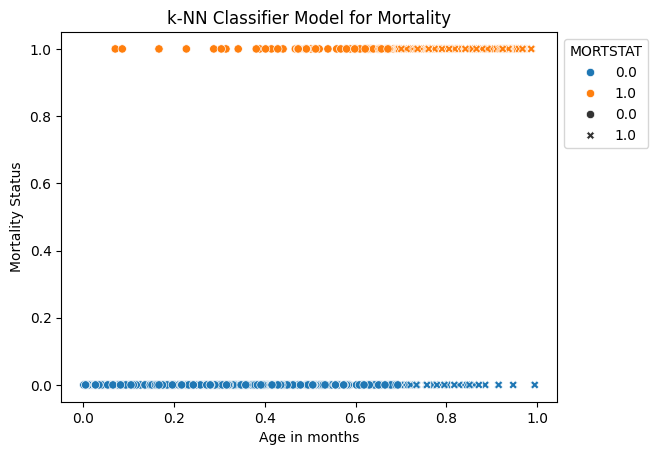

In [51]:
from sklearn.neighbors import KNeighborsClassifier

k = 89 
model = KNeighborsClassifier(n_neighbors = k)
model.fit(u_train,y_train)
y_hat = model.predict(u_test)

u_test_df = pd.DataFrame(u_test, columns=x.columns)
mortality_plot = sns.scatterplot(x = u_test[:, 0],
                y = y_test,
                hue = y_test,
                style=y_hat)
sns.move_legend(mortality_plot, "upper left", bbox_to_anchor=(1, 1))
plt.xlabel('Age in months')
plt.ylabel("Mortality Status")
plt.title("k-NN Classifier Model for Mortality")
plt.show()

In [55]:
pd.crosstab(y_test,y_hat)

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[428,  36],
       [ 60, 123]])

In [53]:
test_acc = model.score(u_test, y_test)
print(test_acc)

0.8516228748068007


### Choosing optimal k

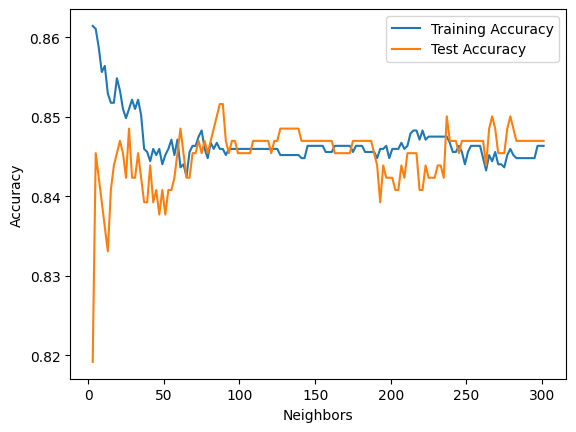

[87 89]


In [50]:
import numpy as np

k_grid = np.array([ (2*k+3) for k in range(0,150)])

test_accuracies = []
train_accuracies = []

for k in k_grid: 
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(u_train,y_train)
    test_accuracies.append(model.score(u_test, y_test))
    train_accuracies.append(model.score(u_train, y_train))
    
sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()

is_optimal = test_accuracies == np.max(test_accuracies)
optimal_indices = np.where( is_optimal )
k_optimal = k_grid[ optimal_indices ]

print(k_optimal)